In [2]:
import numpy as np 
import pandas as pd
import copernicusmarine

/home/momir19/anaconda3/envs/copernicus/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
import os
import shutil

# Define your source directory and your destination directory
search_directory = "/home/momir19/famnit_hackathon2026/model/23sp_4120img_34945annots_2688res"
destination_directory = "/home/momir19/famnit_hackathon2026/model/copied_images"

# Target substring you are searching for
target_string = "IPC608_8B64_165.jpg"

# Create the destination folder automatically if it doesn't exist yet
os.makedirs(destination_directory, exist_ok=True)

print("Starting file separation process...")
print(f"Target substring: '{target_string}'\n" + "-"*50)

copied_count = 0
ignored_count = 0

for root, dirs, files in os.walk(search_directory):
    for file in files:
        # Check if the target string exists anywhere inside the filename
        if target_string in file:
            source_path = os.path.join(root, file)
            destination_path = os.path.join(destination_directory, file)
            
            try:
                # Copy the file to the new folder (overwrites if it already exists there)
                shutil.copy2(source_path, destination_path)
                print(f"[COPIED] -> {file}")
                copied_count += 1
            except Exception as e:
                print(f"[ERROR] Failed to copy {file}: {e}")
                
        else:
            # File does not match; we do nothing, safely keeping it where it is
            ignored_count += 1

print("-"*50)
print(f"Process complete!")
print(f"Total images copied to new folder: {copied_count}")
print(f"Total other images safely left alone: {ignored_count}")

Starting file separation process...
Target substring: 'IPC608_8B64_165.jpg'
--------------------------------------------------
[COPIED] -> 20231006-073401-IPC608_8B64_165.jpg
[COPIED] -> 20230919-065501-IPC608_8B64_165.jpg
[COPIED] -> 20240313-173501-IPC608_8B64_165.jpg
[COPIED] -> 20231004-065901-IPC608_8B64_165.jpg
[COPIED] -> 20230929-104701-IPC608_8B64_165.jpg
[COPIED] -> 20240225-143801-IPC608_8B64_165.jpg
[COPIED] -> 20240411-090213-IPC608_8B64_165.jpg
[COPIED] -> 20231005-094701-IPC608_8B64_165.jpg
[COPIED] -> 20231126-074401-IPC608_8B64_165.jpg
[COPIED] -> 20240411-090316-IPC608_8B64_165.jpg
[COPIED] -> 20230914-110001-IPC608_8B64_165.jpg
[COPIED] -> 20231004-102101-IPC608_8B64_165.jpg
[COPIED] -> 20230730-113036-IPC608_8B64_165.jpg
[COPIED] -> 20240411-090008-IPC608_8B64_165.jpg
[COPIED] -> 20231006-113101-IPC608_8B64_165.jpg
[COPIED] -> 20240429-074401-IPC608_8B64_165.jpg
[COPIED] -> 20230817-120036-IPC608_8B64_165.jpg
[COPIED] -> 20240411-090057-IPC608_8B64_165.jpg
[COPIED] 

In [ ]:
import cv2

def extract_corner_text(image_path, crop_percentage=0.20):
    """
    Crops the top-right and bottom-left corners of an image 
    and uses EasyOCR to extract time, date, or metadata labels.
    """
    # 1. Load image using OpenCV
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image from {image_path}")
        return None, None
        
    h, w, _ = img.shape
    
    # 2. Mathematically define corner bounding box thresholds based on pixel density
    crop_h = int(h * crop_percentage)
    crop_w = int(w * crop_percentage)
    
    # Top-Right Corner Bounding Box Coordinates
    # Y goes from 0 to crop_h, X goes from (width - crop_w) to width
    top_right_crop = img[0:crop_h, (w - crop_w):w]
    
    # Bottom-Left Corner Bounding Box Coordinates
    # Y goes from (height - crop_h) to height, X goes from 0 to crop_w
    bottom_left_crop = img[(h - crop_h):h, 0:crop_w]
    
    # 3. Initialize the Deep Learning OCR Reader (English)
    # It automatically detects and uses a GPU if CUDA is available on your chip
    reader = easyocr.Reader(['en'], gpu=True)
    
    # 4. Perform inference on the cropped arrays
    # detail=0 returns raw string blocks instead of geometric matrix coordinates
    top_right_text = reader.readtext(top_right_crop, detail=0)
    bottom_left_text = reader.readtext(bottom_left_crop, detail=0)
    
    # Clean up array chunks into clean single strings
    top_right_result = " ".join(top_right_text).strip()
    bottom_left_result = " ".join(bottom_left_text).strip()
    
    return top_right_result, bottom_left_result

# --- Execution Example ---
if __name__ == "__main__":
    # Test path from your local structure
    sample_img = "/home/momir19/famnit_hackathon2026/model/23sp_4120img_34945annots_2688res/valid/images/captura_cam2160923143015_00_01.jpg"
    
    print("Initializing AI Inference Engine...")
    top_right, bottom_left = extract_corner_text(sample_img, crop_percentage=0.22)
    
    print("\n================ EXTRACTION RESULTS ================")
    print(f"Top-Right Corner Label (Expected Time/Date): \n👉 {top_right}")
    print(f"Bottom-Left Corner Label (Expected Metadata): \n👉 {bottom_left}")
    print("====================================================")

In [ ]:
from roboflow import Roboflow

# 1. Initialize the Roboflow client with your private API key
# (This replaces '!roboflow login')
rf = Roboflow(api_key="YOUR_PRIVATE_API_KEY")

# 2. Reference your workspace and project details
workspace_name = "lukas-workspace-3ubeb"
project_name = "picking-cotton"

project = rf.workspace(workspace_name).project(project_name)

# 3. Set your data path
# Note: Roboflow python SDK accepts a path to a single image or a directory
dataset_path = "/path/to/data"

# 4. Execute the upload sequentially
import os

if os.path.isdir(dataset_path):
    print(f"Uploading directory: {dataset_path}...")
    # Loop through and upload images if passing a folder
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                full_path = os.path.join(root, file)
                try:
                    project.single_upload(image_path=full_path)
                    print(f"Successfully uploaded: {file}")
                except Exception as e:
                    print(f"Failed to upload {file}: {e}")
else:
    # Upload single file
    print(f"Uploading single file: {dataset_path}")
    project.single_upload(image_path=dataset_path)

print("Upload process completed!")

In [72]:
import matplotlib.pyplot as plt
import cv2
from skimage import measure, feature, color, io
from PIL import Image

def show_img(path,label):
   img_local = Image.open(path)
   img_arr = np.array(img_local)
   # Show preview
   plt.figure(figsize=(12,6))
   plt.imshow(img_arr, cmap="gray"); 
   plt.title(label)
   plt.axis('off')
   plt.show()

def pre_processing(image_sample):

   img_arr = np.array(Image.open(image_sample))
   # Parameters
   alpha = 2 # contrast
   beta = 255   # brightness (0–255)
   # Enhance contrast and brightness
   raw_img = np.clip(img_arr.astype(np.float64) * alpha + beta, 0, 65535).astype(np.float64)
   first_method = raw_img.copy()
   se=cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
   bg=cv2.morphologyEx(first_method, cv2.MORPH_DILATE, se)
   out_gray=cv2.divide(first_method, bg, scale=255)
   out_gray = 255 - out_gray
   intImg = out_gray.astype(np.uint8)
   intImg = cv2.fastNlMeansDenoising(intImg,None,4,10,7)
   blurred = cv2.GaussianBlur(intImg,(3,3),0)
   return blurred


In [41]:
import numpy as np
import cv2
from PIL import Image

def dark_channel(img, patch_size=15):
    """
    Dark Channel Prior — key indicator of haze/turbidity.
    In clear images, dark channel is very dark (low values).
    In turbid images, scattered light raises the dark channel significantly.
    """
    min_channel = np.min(img, axis=2)  # minimum across RGB channels
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, 
        (patch_size, patch_size)
    )
    dark = cv2.erode(min_channel, kernel)
    return dark

def estimate_turbidity(original_rgb_path, blurred_preprocessed):
    """
    Takes the original RGB image path and the preprocessed (blurred) grayscale.
    Returns a turbidity score 0–100 where:
        0  = perfectly clear water
        100 = completely turbid / zero visibility
    """
    # --- Load original RGB (needed for color features) ---
    img_rgb = np.array(Image.open(original_rgb_path)).astype(np.float32)
    if img_rgb.max() > 255:
        img_rgb = (img_rgb / 65535.0 * 255.0)  # normalize 16-bit to 8-bit range
    img_rgb = img_rgb.astype(np.uint8)

    h, w = img_rgb.shape[:2]

    # ── FEATURE 1: Dark Channel Mean ──────────────────────────────────────
    # Higher dark channel = more scattered light = more turbidity
    dc = dark_channel(img_rgb.astype(np.float32) / 255.0, patch_size=15)
    dark_channel_score = float(np.mean(dc)) * 100  # 0–100

    # ── FEATURE 2: Contrast (RMS contrast of preprocessed grayscale) ──────
    # Lower contrast = more turbid
    gray = blurred_preprocessed.astype(np.float32)
    rms_contrast = float(np.std(gray) / 255.0)  # normalize 0–1
    contrast_score = (1.0 - rms_contrast) * 100  # invert: low contrast = high turbidity

    # ── FEATURE 3: Underwater Color Cast Index ────────────────────────────
    # Clear water: red attenuated but image still has structure
    # Turbid water: strong blue/green dominance + red almost gone
    r = img_rgb[:,:,0].astype(np.float32)
    g = img_rgb[:,:,1].astype(np.float32)
    b = img_rgb[:,:,2].astype(np.float32)
    
    mean_r, mean_g, mean_b = np.mean(r), np.mean(g), np.mean(b)
    total = mean_r + mean_g + mean_b + 1e-6

    # Red attenuation ratio: how much red is missing vs green+blue
    red_attenuation = 1.0 - (mean_r / (total / 3.0 + 1e-6))
    red_attenuation = np.clip(red_attenuation, 0, 1)
    color_score = float(red_attenuation) * 100

    # ── FEATURE 4: Blur / Sharpness (Laplacian variance) ─────────────────
    # Turbid water softens edges — low Laplacian variance = blurry = turbid
    laplacian = cv2.Laplacian(blurred_preprocessed, cv2.CV_64F)
    lap_var = float(np.var(laplacian))
    # Empirically, clear underwater images: lap_var > 200
    # Turbid: lap_var < 50. Clip and normalize.
    sharpness_score = (1.0 - np.clip(lap_var / 300.0, 0, 1)) * 100

    # ── FEATURE 5: UICM — Underwater Image Colorfulness Measure ──────────
    # Based on the UIQM metric from the FUnIE-GAN paper you read
    rg = r - g
    yb = 0.5 * (r + g) - b
    mu_rg, sigma_rg = np.mean(rg), np.std(rg)
    mu_yb, sigma_yb = np.mean(yb), np.std(yb)
    uicm = -0.0268 * np.sqrt(mu_rg**2 + mu_yb**2) + 0.1586 * np.sqrt(sigma_rg**2 + sigma_yb**2)
    # UICM is typically negative for turbid, positive for colorful/clear
    # Normalize to 0–100 (higher UICM = clearer)
    uicm_score = (1.0 - np.clip((uicm + 10) / 20.0, 0, 1)) * 100

    # ── WEIGHTED COMBINATION ──────────────────────────────────────────────
    # Weights tuned for diver POV underwater imagery
    weights = {
        "dark_channel": 0.20,  # DOWN from 0.30 — background haze inflates this unfairly
        "contrast":     0.35,  # UP from 0.25 — most reliable signal in this type of image
        "sharpness":    0.30,  # UP from 0.20 — foreground sharpness is the best clarity cue
        "color":        0.05,  # DOWN from 0.15 — red attenuation is depth-related not turbidity
        "uicm":         0.10,  # unchanged
    }
    turbidity_score = (
        weights["dark_channel"] * dark_channel_score +
        weights["contrast"]     * contrast_score     +
        weights["sharpness"]    * sharpness_score     +
        weights["color"]        * color_score         +
        weights["uicm"]         * uicm_score
    )

    turbidity_score = float(np.clip(turbidity_score, 0, 100))

    return {
        "turbidity_score": round(turbidity_score, 2),
        "components": {
            "dark_channel":  round(dark_channel_score, 2),
            "contrast":      round(contrast_score, 2),
            "sharpness":     round(sharpness_score, 2),
            "color_cast":    round(color_score, 2),
            "uicm":          round(uicm_score, 2),
        }
    }


# ── USAGE ─────────────────────────────────────────────────────────────────
def score_image(image_path):
    preprocessed = pre_processing(image_path)   # your existing function
    result = estimate_turbidity(image_path, preprocessed)
    
    print(f"Turbidity Score: {result['turbidity_score']} / 100")
    print(f"  (0 = crystal clear, 100 = zero visibility)")
    print(f"\nBreakdown:")
    for k, v in result["components"].items():
        print(f"  {k:15s}: {v:.1f}")
    
    return result

score_image("/home/momir19/famnit_hackathon2026/model/copied_images/20230917-102501-IPC608_8B64_165.jpg")

Turbidity Score: 74.09 / 100
  (0 = crystal clear, 100 = zero visibility)

Breakdown:
  dark_channel   : 39.4
  contrast       : 98.0
  sharpness      : 96.9
  color_cast     : 10.9
  uicm           : 22.9


{'turbidity_score': 74.09,
 'components': {'dark_channel': 39.37,
  'contrast': 98.01,
  'sharpness': np.float64(96.93),
  'color_cast': 10.93,
  'uicm': np.float32(22.88)}}

In [ ]:
import os
from datetime import datetime

# 1. Fixed the os.walk unpacking sequence (root, dirs, files)
search_directory = "/home/momir19/famnit_hackathon2026/model/copied_images"
rows = []
for root, dirs, files in os.walk(search_directory):
    for file in files:
        filename_string = file[:15]
        dt_object = datetime.strptime(filename_string, "%Y%m%d-%H%M%S")
        readable_date = dt_object.strftime("%d-%m-%Y")
        readable_time = dt_object.strftime("%H:%M:%S")
        path = os.path.join(root, file)
        print(f"Absolute Path: {path}")
        metrics = score_image("/home/momir19/famnit_hackathon2026/model/copied_images/20230917-102501-IPC608_8B64_165.jpg")
        row_data = {
            "Filename": file,
            "Date": readable_date,
            "Time": readable_time,
            "Longitude": 1.75257,
            "Latitude": 41.18212,
            "Depth(m)": 20,
            "Turbidity_Score": metrics["turbidity_score"],
            "Dark_Channel": metrics["components"]["dark_channel"],
            "Contrast": metrics["components"]["contrast"],
            "Sharpness": metrics["components"]["sharpness"],
            "Color_Cast": metrics["components"]["color_cast"],
            "UICM": metrics["components"]["uicm"]
        }
        
        rows.append(row_data)
           

Absolute Path: /home/momir19/famnit_hackathon2026/model/copied_images/20230918-055002-IPC608_8B64_165.jpg
Turbidity Score: 74.09 / 100
  (0 = crystal clear, 100 = zero visibility)

Breakdown:
  dark_channel   : 39.4
  contrast       : 98.0
  sharpness      : 96.9
  color_cast     : 10.9
  uicm           : 22.9
Absolute Path: /home/momir19/famnit_hackathon2026/model/copied_images/20231006-073401-IPC608_8B64_165.jpg
Turbidity Score: 74.09 / 100
  (0 = crystal clear, 100 = zero visibility)

Breakdown:
  dark_channel   : 39.4
  contrast       : 98.0
  sharpness      : 96.9
  color_cast     : 10.9
  uicm           : 22.9
Absolute Path: /home/momir19/famnit_hackathon2026/model/copied_images/20230730-083036-IPC608_8B64_165.jpg
Turbidity Score: 74.09 / 100
  (0 = crystal clear, 100 = zero visibility)

Breakdown:
  dark_channel   : 39.4
  contrast       : 98.0
  sharpness      : 96.9
  color_cast     : 10.9
  uicm           : 22.9
Absolute Path: /home/momir19/famnit_hackathon2026/model/copied_i

KeyboardInterrupt: 

In [53]:
import torch
import open_clip
import cv2
import numpy as np

print(f"📦 PyTorch Version: {torch.__version__}")
print(f"🚀 CUDA Available?   {torch.cuda.is_available()}")
print(f"🦅 Open-CLIP Version: {open_clip.__version__}")

📦 PyTorch Version: 2.11.0
🚀 CUDA Available?   True
🦅 Open-CLIP Version: 2.32.0


In [ ]:
import os
import torch
import open_clip
import pandas as pd
from PIL import Image
from datetime import datetime
from tqdm import tqdm  # Run '!pip install tqdm' if missing for a progress bar

# 1. Initialize Open-CLIP Model Environment
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using execution device: {device.upper()}")

# Loading the lightweight but powerful ViT-B-32 model
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device=device)
tokenizer = open_clip.get_tokenizer('ViT-B-32')

# 2. Tailor Contextual Prompts for Underwater Optical Behavior
# This prevents the AI from flagging natural water glow/particles as camera blur
labels = [
    "a clear underwater photo with sharp details", 
    "a blurry, murky, out-of-focus underwater photo"
]
text_input = tokenizer(labels).to(device)

def process_underwater_dataset(search_directory, output_csv_path="underwater_clarity_results.csv"):
    rows = []
    
    # Gather files first to feed the progress bar accurately
    all_files = []
    for root, dirs, files in os.walk(search_directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff')):
                all_files.append((root, file))
                
    print(f"Found {len(all_files)} target images. Commencing AI evaluation pipeline...")

    # 3. Main Processing Loop with Real-Time Progress Bar
    for root, file in tqdm(all_files, desc="Evaluating Visibility Status"):
        image_path = os.path.join(root, file)
        
        try:
            # Parse Date and Time from Filename Prefix (e.g., '20230730-083036')
            filename_string = file[:15]
            dt_object = datetime.strptime(filename_string, "%Y%m%d-%H%M%S")
            readable_date = dt_object.strftime("%d.%m.%Y") # European format
            readable_time = dt_object.strftime("%H:%M:%S")
            
            # Load and convert image to Open-CLIP Tensor
            image = Image.open(image_path).convert("RGB")
            image_input = preprocess(image).unsqueeze(0).to(device)
            
            # Run Tensor Inference
            with torch.no_grad(), torch.cuda.amp.autocast():
                image_features = model.encode_image(image_input)
                text_features = model.encode_text(text_input)
                
                # Normalize Vectors for Cosine Similarity Matrice
                image_features /= image_features.norm(dim=-1, keepdim=True)
                text_features /= text_features.norm(dim=-1, keepdim=True)
                
                # Softmax Conversion to Probability Percentages
                similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
                probs = similarity.cpu().numpy()[0]
            
            clear_score = float(probs[0] * 100)
            blurry_score = float(probs[1] * 100)
            status = "Clear" if clear_score > blurry_score else "Blurry"
            
            # Compile Dataset Row Attributes
            rows.append({
                "Filename": file,
                "Date": readable_date,
                "Time": readable_time,
                "Clarity_Confidence_%": round(clear_score, 2),
                "Blurry_Confidence_%": round(blurry_score, 2),
                "Visibility_Status": status,
                "Absolute_Path": image_path
            })
            
        except ValueError:
            # Safely skip files that don't match the timestamp naming pattern
            continue
        except Exception as e:
            # Ensure a single corrupted image file doesn't crash a 2000-image run
            print(f"\n⚠️ Error processing {file}: {e}")
            continue

    # 4. Save and Export Data Summary
    if rows:
        df_results = pd.DataFrame(rows)
        # Sort chronologically by date/time order
        df_results = df_results.sort_values(by=["Date", "Time"]).reset_index(drop=True)
        df_results.to_csv(output_csv_path, index=False)
        print(f"\n✅ Pipeline Complete! Dataset compiled and saved to: {output_csv_path}")
        return df_results
    else:
        print("\n❌ No valid image data compiled.")
        return None

# ==========================================
# EXECUTION COMMANDS
# ==========================================
target_folder = "/home/momir19/famnit_hackathon2026/model/copied_images"
csv_destination = "underwater_clarity_matrix.csv"

df_final = process_underwater_dataset("/home/momir19/famnit_hackathon2026/model/copied_images", csv_destination)

# Display a preview of the finished framework inside your notebook
if df_final is not None:
    display(df_final.head(10))

🖥️ Execution Device set to: CPU


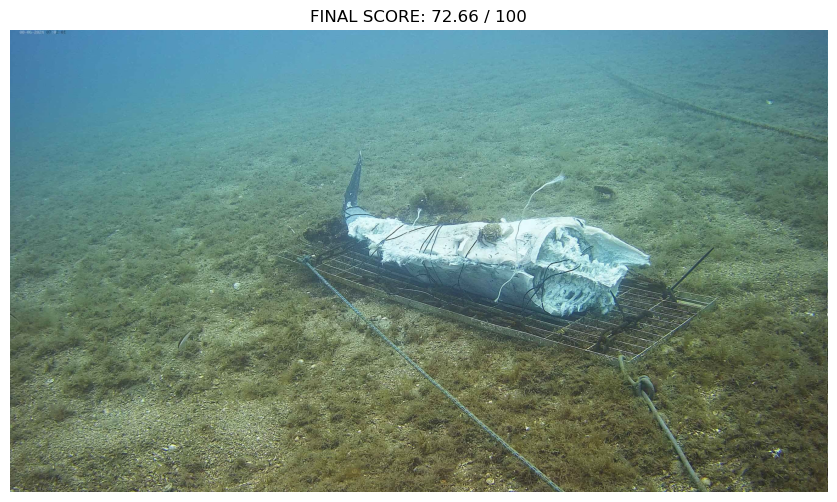

In [ ]:
import os
import torch
import open_clip
from PIL import Image
import traceback

# 1. FORCE CPU EXPLICITLY (Bypasses false CUDA driver detection)
device = "cpu"
print(f"🖥️ Execution Device set to: {device.upper()}")

# Initialize Open-CLIP directly on the CPU
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device=device)
model.eval()  # Set model to evaluation mode
tokenizer = open_clip.get_tokenizer('ViT-B-32')

# Define text labels
labels = [
    "a clear underwater photo with sharp details", 
    "a blurry, murky, completely invisible underwater photo"
]
text_input = tokenizer(labels).to(device)

def get_invisible_score_cpu(image_path):
    """
    Computes an underwater turbidity score from 0 (clear) to 100 (invisible).
    Strictly optimized for CPU execution.
    """
    if not os.path.exists(image_path):
        print(f"❌ File not found: {image_path}")
        return None
        
    try:
        # Load image and convert to RGB
        image = Image.open(image_path).convert("RGB")
        
        # Preprocess image into CPU tensor
        image_input = preprocess(image).unsqueeze(0).to(device)
        
        # Pure CPU forward pass (No autocast needed for CPU)
        with torch.no_grad():
            image_features = model.encode_image(image_input)
            text_features = model.encode_text(text_input)
            
            # Normalize vectors
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            
            # Compute similarity matrix
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            
            # Extract directly to numpy (no .cpu() step required)
            probs = similarity.numpy()[0]
        
        # Extract probability of index 1 ("invisible")
        invisible_score = float(probs[1] * 100)
        return round(invisible_score, 2)
        
    except Exception as e:
        print(f"❌ CPU Pipeline Failure: {e}")
        traceback.print_exc()
        return None

# --- RUN THE CPU TEST ---
img_path = "/home/momir19/famnit_hackathon2026/model/copied_images/20240608-070201-IPC608_8B64_165.jpg"
score = get_invisible_score_cpu(img_path)


In [63]:
img_path = "/home/momir19/famnit_hackathon2026/model/copied_images/20230730-083036-IPC608_8B64_165.jpg"
score = get_invisible_score(img_path)

print(f"Turbidity/Invisibility Score: {score} / 100")

❌ Runtime pipeline failure on 20230730-083036-IPC608_8B64_165.jpg: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Turbidity/Invisibility Score: None / 100


In [80]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import open_clip
from PIL import Image
from tqdm import tqdm

# =====================================================================
# 1. SETUP ENVIRONMENT AND LOAD MODEL
# =====================================================================
device = "cpu"
print(f"🖥️ Training Mode Initialized on: {device.upper()}")

model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device=device)
tokenizer = open_clip.get_tokenizer('ViT-B-32')

# Explicitly enable gradients for training
model.train()

# Define the anchor text prompts
labels = [
    "a clear underwater photo with sharp details", 
    "a blurry, murky, completely invisible underwater photo"
]
text_tokens = tokenizer(labels).to(device)

# =====================================================================
# 2. DEFINE CUSTOM CUSTOM DATASET
# =====================================================================
class UnderwaterTurbidityDataset(Dataset):
    def __init__(self, data_list, image_dir, transform):
        """
        data_list: List of tuples containing (filename, score_0_to_100)
        """
        self.data_list = data_list
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        filename, score = self.data_list[idx]
        img_path = os.path.join(self.image_dir, filename)
        
        # Load and transform image
        image = Image.open(img_path).convert("RGB")
        image_tensor = self.transform(image)
        
        # Convert 0-100 score to soft target distribution: [Clear, Invisible]
        invisible_prob = score / 100.0
        clear_prob = 1.0 - invisible_prob
        target_distribution = torch.tensor([clear_prob, invisible_prob], dtype=torch.float32)
        
        return image_tensor, target_distribution

# =====================================================================
# 3. PREPARE TRAINING DATA
# =====================================================================
# Injecting the manual labels you just curated
curated_data = [
    ("20231006-111401-IPC608_8B64_165.jpg", 79),
    ("20231008-090501-IPC608_8B64_165.jpg", 7),
    ("20231008-112501-IPC608_8B64_165.jpg", 17),
    ("20231012-065901-IPC608_8B64_165.jpg", 51),
    ("20231012-082301-IPC608_8B64_165.jpg", 63),
    ("20231016-155601-IPC608_8B64_165.jpg", 88),
    ("20231017-060501-IPC608_8B64_165.jpg", 94),
    ("20231017-071401-IPC608_8B64_165.jpg", 6),
    ("20231018-064001-IPC608_8B64_165.jpg", 65),
    ("20231018-071801-IPC608_8B64_165.jpg", 53),
    ("20231018-093502-IPC608_8B64_165.jpg", 64),
    ("20231026-075201-IPC608_8B64_165.jpg", 86),
    ("20231026-110401-IPC608_8B64_165.jpg", 90),
    ("20231026-111801-IPC608_8B64_165.jpg", 93),
    ("20231026-162401-IPC608_8B64_165.jpg", 96),
    ("20231202-142401-IPC608_8B64_165.jpg", 99),
    ("20240215-093801-IPC608_8B64_165.jpg", 100),
    ("20240205-101601-IPC608_8B64_165.jpg", 38),
    ("20240321-090001-IPC608_8B64_165.jpg", 58),
    ("20240530-112601-IPC608_8B64_165.jpg", 36),
    ("20240530-182901-IPC608_8B64_165.jpg", 63),
    ("20240531-085101-IPC608_8B64_165.jpg", 38),
    ("20240610-080602-IPC608_8B64_165.jpg", 19),
    ("20240610-084501-IPC608_8B64_165.jpg", 16),
    ("20240321-085501-IPC608_8B64_165.jpg", 43),
    ("20240319-125301-IPC608_8B64_165.jpg", 78),
    ("20240315-082601-IPC608_8B64_165.jpg", 87),
    ("20240309-073601-IPC608_8B64_165.jpg", 93),
    ("20240308-080501-IPC608_8B64_165.jpg", 36),
    ("20240229-132601-IPC608_8B64_165.jpg", 96),
    ("20240205-085101-IPC608_8B64_165.jpg", 41),
    ("20240131-105401-IPC608_8B64_165.jpg", 13),
    ("20240130-095901-IPC608_8B64_165.jpg", 54),
    ("20231130-101301-IPC608_8B64_165.jpg", 73),
    ("20231129-105101-IPC608_8B64_165.jpg", 84),
    ("20231126-154001-IPC608_8B64_165.jpg", 86),
    ("20231112-090401-IPC608_8B64_165.jpg", 55),
    ("20231018-091301-IPC608_8B64_165.jpg", 32),
    ("20231018-083501-IPC608_8B64_165.jpg", 16),
    ("20231017-082301-IPC608_8B64_165.jpg", 23),
    ("20231018-081301-IPC608_8B64_165.jpg", 28),
    ("20231017-114001-IPC608_8B64_165.jpg", 41),
    ("20240426-102801-IPC608_8B64_165.jpg", 70),
    ("20240425-162101-IPC608_8B64_165.jpg", 85),
    ("20240401-154601-IPC608_8B64_165.jpg", 92),
    ("20240326-010036-IPC608_8B64_165.jpg", 98),
    ("20240323-110401-IPC608_8B64_165.jpg", 30),
    ("20240312-085801-IPC608_8B64_165.jpg", 99),
    ("20231018-073001-IPC608_8B64_165.jpg", 15),
    ("20240503-072201-IPC608_8B64_165.jpg", 80),
    ("20240407-154301-IPC608_8B64_165.jpg", 100),
    ("20240205-085301-IPC608_8B64_165.jpg", 55),
    ("20230723-060036-IPC608_8B64_165.jpg", 50),
    ("20230730-093036-IPC608_8B64_165.jpg", 20),
    ("20230807-083037-IPC608_8B64_165.jpg", 30),
    ("20230821-063036-IPC608_8B64_165.jpg", 0),
    ("20230821-173036-IPC608_8B64_165.jpg", 78),
    ("20230815-110036-IPC608_8B64_165.jpg", 55),
    ("20230914-133501-IPC608_8B64_165.jpg", 85),
    ("20230917-104501-IPC608_8B64_165.jpg", 30),
    ("20230919-075001-IPC608_8B64_165.jpg", 20),
    ("20230919-083001-IPC608_8B64_165.jpg", 12),
    ("20230926-100501-IPC608_8B64_165.jpg", 22),
    ("20231001-123101-IPC608_8B64_165.jpg", 70),
    ("20231007-083301-IPC608_8B64_165.jpg", 43),
    ("20231002-102401-IPC608_8B64_165.jpg", 70),
    ("20231002-124401-IPC608_8B64_165.jpg", 83),
    ("20231003-063901-IPC608_8B64_165.jpg", 90),
    ("20231004-082701-IPC608_8B64_165.jpg", 35),
    ("20231006-070501-IPC608_8B64_165.jpg", 60),
    ("20240603-140201-IPC608_8B64_165.jpg", 22),
    ("20240602-184601-IPC608_8B64_165.jpg", 14),
    ("20240531-091301-IPC608_8B64_165.jpg", 41),
    ("20240422-102301-IPC608_8B64_165.jpg", 68),
    ("20240420-141201-IPC608_8B64_165.jpg", 89),
    ("20240411-094701-IPC608_8B64_165.jpg", 57),
    ("20230927-092501-IPC608_8B64_165.jpg", 21),
    ("20231002-063501-IPC608_8B64_165.jpg", 30),
    ("20230929-065201-IPC608_8B64_165.jpg", 72),
    ("20231003-071701-IPC608_8B64_165.jpg", 95),
    ("20231003-091501-IPC608_8B64_165.jpg", 85),
    ("20231003-102901-IPC608_8B64_165.jpg", 71),
    ("20231003-121901-IPC608_8B64_165.jpg", 83),
    ("20231009-071901-IPC608_8B64_165.jpg", 32),
    ("20231008-100201-IPC608_8B64_165.jpg", 21),
    ("20240530-112701-IPC608_8B64_165.jpg", 23),
    ("20240602-184501-IPC608_8B64_165.jpg", 8),
    ("20240608-050001-IPC608_8B64_165.jpg", 10),
    ("20230801-083036-IPC608_8B64_165.jpg", 22),
    ("20230915-063501-IPC608_8B64_165.jpg", 46),
    ("20230916-055001-IPC608_8B64_165.jpg", 27),
    ("20230916-072501-IPC608_8B64_165.jpg", 22),
    ("20230917-084501-IPC608_8B64_165.jpg", 16),
    ("20230918-082001-IPC608_8B64_165.jpg", 23),
    ("20230927-104001-IPC608_8B64_165.jpg", 32),
    ("20230927-124501-IPC608_8B64_165.jpg", 74),
    ("20230928-062601-IPC608_8B64_165.jpg", 94),
    ("20230929-054701-IPC608_8B64_165.jpg", 96),
    ("20230929-083301-IPC608_8B64_165.jpg", 98),
    ("20231002-060301-IPC608_8B64_165.jpg", 32),
    ("20231002-090701-IPC608_8B64_165.jpg", 23),
    ("20231002-131901-IPC608_8B64_165.jpg", 83),
    ("20231003-061601-IPC608_8B64_165.jpg", 93),
    ("20231003-062401-IPC608_8B64_165.jpg", 93),
    ("20231006-081101-IPC608_8B64_165.jpg", 93),
]
image_directory = "/home/momir19/famnit_hackathon2026/model/copied_images"

dataset = UnderwaterTurbidityDataset(curated_data, image_directory, preprocess)
# Batch size is small because CPU optimization thrives on steady incremental adjustments
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# =====================================================================
# 4. OPTIMIZER & LOSS FUNCTION
# =====================================================================
# A tiny learning rate is critical for CLIP so you don't ruin its pretrained visual knowledge
optimizer = optim.AdamW(model.parameters(), lr=5e-6, weight_decay=0.2)

def soft_cross_entropy(predicted_logits, target_distributions):
    """
    Computes cross entropy loss against soft probability matrices.
    """
    log_probs = torch.nn.functional.log_softmax(predicted_logits, dim=-1)
    return torch.mean(torch.sum(-target_distributions * log_probs, dim=-1))

# =====================================================================
# 5. TRAINING LOOP
# =====================================================================
epochs = 10
print(f"Beginning fine-tuning across {epochs} epochs...")

for epoch in range(epochs):
    running_loss = 0.0
    for images, targets in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        images = images.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        # Extract features
        image_features = model.encode_image(images)
        text_features = model.encode_text(text_tokens)
        
        # Normalize embeddings
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        # Compute dot product similarities scaled by CLIP's internal temperature parameter
        logit_scale = model.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.T
        
        # Run Loss and Backpropagation
        loss = soft_cross_entropy(logits_per_image, targets)
        loss.backward()
        
        optimizer.step()
        running_loss += loss.item()
        
    print(f"🏁 Epoch {epoch+1} Complete. Average Loss: {round(running_loss / len(dataloader), 4)}")

# Save weights locally
output_weight_path = "custom_underwater_openclip.pt"
torch.save(model.state_with_num_workers() if hasattr(model, 'state_with_num_workers') else model.state_dict(), output_weight_path)
print(f"✅ Trained model weights safely exported to: {output_weight_path}")

🖥️ Training Mode Initialized on: CPU
Beginning fine-tuning across 10 epochs...


Epoch 1/10: 100%|██████████| 27/27 [01:22<00:00,  3.05s/it]


🏁 Epoch 1 Complete. Average Loss: 0.7767


Epoch 2/10: 100%|██████████| 27/27 [01:20<00:00,  2.97s/it]


🏁 Epoch 2 Complete. Average Loss: 0.508


...

🏁 Epoch 8 Complete. Average Loss: 0.4696


Epoch 9/10: 100%|██████████| 27/27 [01:03<00:00,  2.35s/it]


🏁 Epoch 9 Complete. Average Loss: 0.4784


Epoch 10/10: 100%|██████████| 27/27 [01:05<00:00,  2.42s/it]


🏁 Epoch 10 Complete. Average Loss: 0.4827
✅ Trained model weights safely exported to: custom_underwater_openclip.pt


🖥️ Loading model on device: CPU
🎯 Successfully loaded custom fine-tuned weights from: custom_underwater_openclip.pt


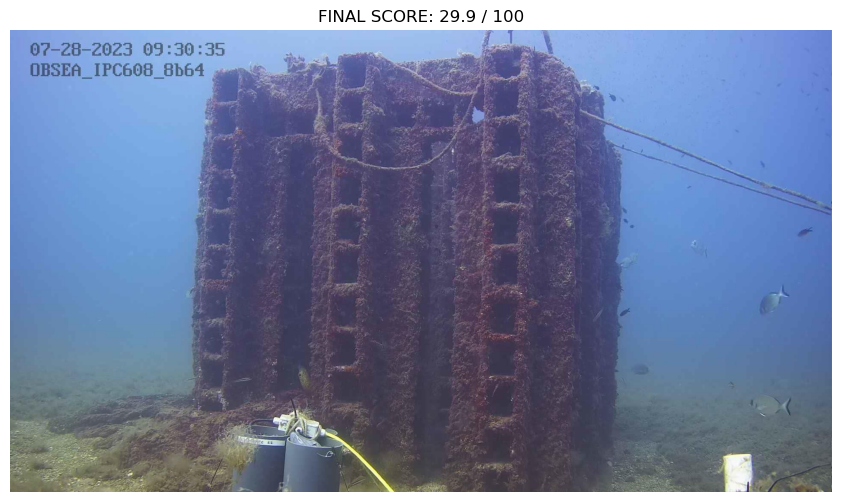

In [81]:
import os
import torch
import open_clip
from PIL import Image

# 1. Force CPU and Initialize the base Open-CLIP Architecture
device = "cpu"
print(f"🖥️ Loading model on device: {device.upper()}")

model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device=device)
tokenizer = open_clip.get_tokenizer('ViT-B-32')

# 2. Inject your fine-tuned weights file
weights_path = "custom_underwater_openclip.pt"

if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"🎯 Successfully loaded custom fine-tuned weights from: {weights_path}")
else:
    print(f"⚠️ Warning: {weights_path} not found! Using standard pretrained weights instead.")

# 3. CRITICAL: Switch the model to Evaluation Mode
# This turns off dropout layers so your scoring is deterministic and consistent
model.eval()

# 4. Tokenize your anchor phrases
labels = [
    "a clear underwater photo with sharp details", 
    "a blurry, murky, completely invisible underwater photo"
]
text_input = tokenizer(labels).to(device)


# 5. Define the scoring function
def get_fine_tuned_invisible_score(image_path):
    """
    Computes your custom turbidity score (0-100) using the fine-tuned model.
    """
    if not os.path.exists(image_path):
        print(f"❌ File not found: {image_path}")
        return None
        
    try:
        # Load and preprocess image
        image = Image.open(image_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to(device)
        
        # Calculate features without tracking gradients (faster inference)
        with torch.no_grad():
            image_features = model.encode_image(image_input)
            text_features = model.encode_text(text_input)
            
            # Normalize embeddings
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            
            # Compute scaled cosine similarity matching the training pipeline setup
            logit_scale = model.logit_scale.exp()
            similarity = (logit_scale * image_features @ text_features.T).softmax(dim=-1)
            
            probs = similarity.numpy()[0]
        
        # Map back to your custom 0-100 invisibility metric
        invisible_score = float(probs[1] * 100)
        return round(invisible_score, 2)
        
    except Exception as e:
        print(f"❌ Scoring Pipeline Failure: {e}")
        return None

# ─── RUN SCORING TEST ───
img_path = "/home/momir19/famnit_hackathon2026/model/copied_images/20230728-093036-IPC608_8B64_165.jpg"
score = get_fine_tuned_invisible_score(img_path)

show_img(img_path, f"FINAL SCORE: {score} / 100" )

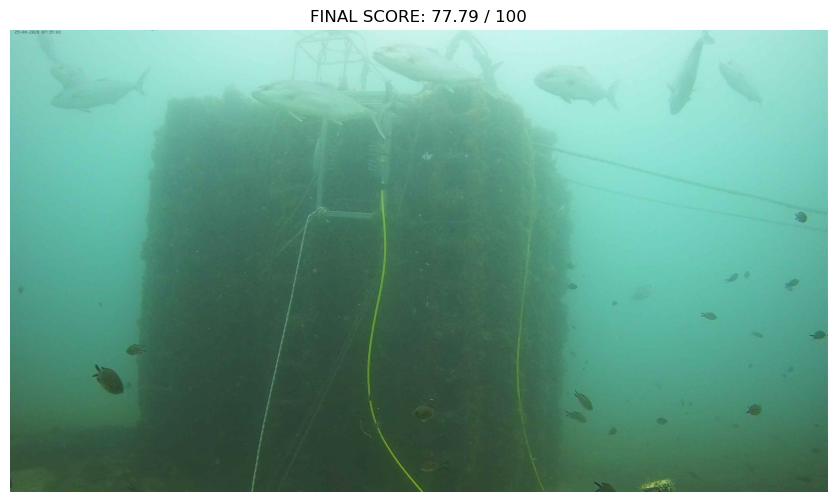

In [82]:

img_path = "/home/momir19/famnit_hackathon2026/model/copied_images/20240429-073901-IPC608_8B64_165.jpg"
score = get_fine_tuned_invisible_score("/home/momir19/famnit_hackathon2026/model/copied_images/20240429-073901-IPC608_8B64_165.jpg")
show_img(img_path, f"FINAL SCORE: {score} / 100" )

In [90]:
import os
import pandas as pd
from datetime import datetime
from tqdm import tqdm

csv_destination = "underwater_clarity_matrix.csv"
rows = []

# FIX 1: Corrected os.walk tuple unpacking order to (root, dirs, files)
search_dir = "/home/momir19/famnit_hackathon2026/model/copied_images"

for root, dirs, files in os.walk(search_dir):
    print(f"Scanning directory: {root}")
    print(f"Found {len(files)} total files.")
    
    # Run progress bar over the actual file string list
    for file in tqdm(files, desc="Processing images"):
        # Make sure we only read valid images
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            
            try:
                # Parse Date and Time from Filename Prefix (e.g., '20230730-083036')
                filename_string = file[:15]
                dt_object = datetime.strptime(filename_string, "%Y%m%d-%H%M%S")
                
                readable_date = dt_object.strftime("%d.%m.%Y") # European format
                readable_time = dt_object.strftime("%H:%M:%S")
                
                # FIX 2: root now points to the correct absolute string directory path
                file_path = os.path.join(root, file)
                
                # Fetch your fine-tuned score
                score = get_fine_tuned_invisible_score(file_path)
                
                # Compile Dataset Row Attributes
                rows.append({
                    "Filename": file,
                    "Date": readable_date,
                    "Time": readable_time,
                    "Visibility_Score": score,
                    "Longitude": 1.75257,
                    "Latitude": 41.18212,
                    "Depth(m)": 20,
                })
                
            except ValueError:
                # Safely skip hidden assets or files that don't match your prefix pattern
                continue
            except Exception as e:
                print(f"\n⚠️ Error processing individual file {file}: {e}")
                continue

# Check if we successfully gathered data
if rows:
    # 1. Initialize DataFrame
    df_results = pd.DataFrame(rows)
    
    # 2. Python 3.14 Bulletproof Native Sort (Bypasses the pandas lexsort_indexer bug)
    raw_rows = df_results.to_dict(orient='records')
    raw_rows.sort(key=lambda x: (x['Date'], x['Time']))
    df_results = pd.DataFrame(raw_rows)
    
    # 3. Export clean results
    df_results.to_csv(csv_destination, index=False)
    print(f"\n✅ Pipeline Complete! Dataset compiled and saved to: {csv_destination}")
    
    # Display preview in notebook
    display(df_results.head(10))
else:
    print("\n❌ Errors or empty folders detected. No matching rows were extracted.")

Scanning directory: /home/momir19/famnit_hackathon2026/model/copied_images
Found 1916 total files.


Processing images: 100%|██████████| 1916/1916 [10:24<00:00,  3.07it/s]



✅ Pipeline Complete! Dataset compiled and saved to: underwater_clarity_matrix.csv


,Filename,Date,Time,Visibility_Score,Longitude,Latitude,Depth(m)
0,20240201-122501-IPC608_8B64_165.jpg,01.02.2024,12:25:01,65.07,1.75257,41.18212,20
1,20240201-125601-IPC608_8B64_165.jpg,01.02.2024,12:56:01,71.93,1.75257,41.18212,20
2,20240301-075701-IPC608_8B64_165.jpg,01.03.2024,07:57:01,77.90,1.75257,41.18212,20
3,20240301-094901-IPC608_8B64_165.jpg,01.03.2024,09:49:01,80.53,1.75257,41.18212,20
4,20240401-090101-IPC608_8B64_165.jpg,01.04.2024,09:01:01,73.69,1.75257,41.18212,20
5,20240401-114401-IPC608_8B64_165.jpg,01.04.2024,11:44:01,66.81,1.75257,41.18212,20
6,20240401-134401-IPC608_8B64_165.jpg,01.04.2024,13:44:01,71.58,1.75257,41.18212,20
7,20240401-134801-IPC608_8B64_165.jpg,01.04.2024,13:48:01,85.55,1.75257,41.18212,20
8,20240401-154601-IPC608_8B64_165.jpg,01.04.2024,15:46:01,86.55,1.75257,41.18212,20
9,20240401-155901-IPC608_8B64_165.jpg,01.04.2024,15:59:01,85.10,1.75257,41.18212,20


In [62]:
external_api_df = pd.read_csv("datetimetempinfo.csv")



processed_scores_df = pd.read_csv("underwater_clarity_matrix.csv")
print(len(external_api_df))
print(len(processed_scores_df))

processed_scores_df.rename(columns={'Filename': 'filename'}, inplace=True)

complete_df = pd.merge(processed_scores_df, external_api_df, on="filename", how="inner")

1916
1916


In [63]:
print(complete_df.columns.tolist())
complete_df.drop(columns=["Date", "Time","datetime_iso", "longitude", "latitude"], inplace=True)
complete_df.to_csv("merged_fetch_scores.csv", index=False)

# Helper to convert "HH:MM" or ISO strings to minutes from midnight
def to_minutes(series, fmt=None):
    return pd.to_datetime(series, format=fmt, errors='coerce').dt.hour * 60 + \
           pd.to_datetime(series, format=fmt, errors='coerce').dt.minute

# Convert time strings to fractional hours (e.g., "12:30:00" -> 12.5)
time_hours = pd.to_datetime(complete_df['time'], format='%H:%M:%S').dt.hour + \
             pd.to_datetime(complete_df['time'], format='%H:%M:%S').dt.minute / 60.0

date_obj = pd.to_datetime(complete_df['date'], format='%d.%m.%Y', errors='coerce')

true_datetime = pd.to_datetime(complete_df['filename'].str[:15], format='%Y%m%d-%H%M%S', errors='coerce')
day_of_year = true_datetime.dt.dayofyear

# Extract raw minutes from midnight for all three factors
img_min = to_minutes(complete_df['time'], fmt='%H:%M:%S')
sunrise_min = to_minutes(complete_df['sunrise'])  # Assumes '2023-07-20T06:37' or '06:37'
sunset_min = to_minutes(complete_df['sunset'])

# Feature 1: Total Daylight Duration in minutes (useful for seasonal context)
complete_df['daylight_duration_mins'] = sunset_min - sunrise_min

# Feature 2: Minutes since sunrise (Negative means it is still pre-dawn dark)
complete_df['mins_since_sunrise'] = img_min - sunrise_min

# Feature 3: Minutes until sunset (Negative means it is post-dusk dark)
complete_df['mins_until_sunset'] = sunset_min - img_min

# Feature 4: Binary Light Indicator (Is the sun up right now? 1=Yes, 0=No)
complete_df['is_daylight'] = ((img_min >= sunrise_min) & (img_min <= sunset_min)).astype(int)
# Convert date string to standard datetime object

# Map to a 365-day annual cycle
complete_df['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
complete_df['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
# Map to a 24-hour cycle
complete_df['time_sin'] = np.sin(2 * np.pi * time_hours / 24.0)
complete_df['time_cos'] = np.cos(2 * np.pi * time_hours / 24.0)

print(complete_df["time_sin"])
print(day_of_year)

['filename', 'Date', 'Time', 'Visibility_Score', 'Longitude', 'Latitude', 'Depth(m)', 'date', 'time', 'longitude', 'latitude', 'depth_m', 'datetime_iso', 'wave_height_m', 'wave_direction_deg', 'wave_period_s', 'wave_peak_period_s', 'sea_surface_temperature_c', 'air_temperature_c', 'wind_speed_kmh', 'wind_direction_deg', 'cloud_cover_pct', 'humidity_pct', 'sunrise', 'sunset', 'moon_phase']
0      -0.108867
1      -0.241922
2       0.872496
3       0.540974
4       0.704015
          ...   
1911   -0.130526
1912   -0.382683
1913   -0.608761
1914    1.000000
1915    0.866025
Name: time_sin, Length: 1916, dtype: float64
0        32
1        32
2        61
3        61
4        92
       ... 
1911    212
1912    212
1913    212
1914    243
1915    243
Name: filename, Length: 1916, dtype: int32


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split



# 2. Define your features (X) 
# Drop the target column and any non-numeric string identifier columns

# Drop columns that are pure strings with no useful info for XGBoost
drop_cols = ["Filename","filename", "date", "time", "sunrise", "sunset"]
complete_df = complete_df.drop(columns=[c for c in drop_cols if c in complete_df.columns])

# If you want to keep sunrise/sunset as useful features, convert to minutes since midnight
for col in ["sunrise", "sunset"]:
    if col in complete_df.columns:
        complete_df[col + "_minutes"] = pd.to_datetime(complete_df[col], errors="coerce").dt.hour * 60 + pd.to_datetime(complete_df[col], errors="coerce").dt.minute

# Double check — print any remaining non-numeric columns
non_numeric = complete_df.select_dtypes(exclude=["int", "float", "bool", "category"]).columns.tolist()
print(f"Non-numeric columns still present: {non_numeric}")

# Final feature matrix
feature_cols = [c for c in complete_df.columns if c != "Score"]
X = complete_df[feature_cols].astype(float)
# 1. Define your target variable (y)
y = complete_df['Visibility_Score']



model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
model.fit(X, y)

NameError: name 'df' is not defined

In [65]:
model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
model.fit(X, y)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:date: str, time: str, sunrise: str, sunset: str